<a href="https://colab.research.google.com/github/Yanina2105/MD-Lab13_FT/blob/develop/LABORATORIO_13_AJUSTE_DE_HIPERPAR%C3%81METROS_DE_UN_MODELO_ESTRATEGIAS_DE_COMPARACI%C3%93N_Y_EVALUACI%C3%93N_DE_DIFERENTES_MODELOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 13: AJUSTE DE HIPERPARÁMETROS DE UN MODELO. ESTRATEGIAS DE COMPARACIÓN Y EVALUACIÓN DE DIFERENTES MODELOS**

Tomando la información disponible en el repositorio UCI Machine Learning
https://archive.ics.uci.edu/ml/datasets/Productivity+Prediction+of+Garment+Employees, pero
eliminando previamente a la variable ‘date’ y definiendo a la variable ‘actual_productivity’ con
base a dos categorías (0 cuando ‘actual_productivity’ < 0.5 y 1 cuando ‘actual_productivity’ ≥ 0.5)
siendo esta la variable de clasificación, haga lo siguiente:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
# Cargar datos
df = pd.read_csv('garments_worker_productivity.csv')

In [3]:
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


## **a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes y tratamiento de outliers a nivel univariado y multivariado. Además, convierta las variables categóricas a dummies y aplique un escalamiento a las variables numéricas.**

In [7]:
df.drop(columns=['date'], inplace=True)

KeyError: "['date'] not found in axis"

In [8]:
df['actual_productivity'] = (df['actual_productivity'] >= 0.5).astype(int)

In [6]:
print(df.isnull().sum())

quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


In [9]:
df.fillna(df.median(numeric_only=True), inplace=True)

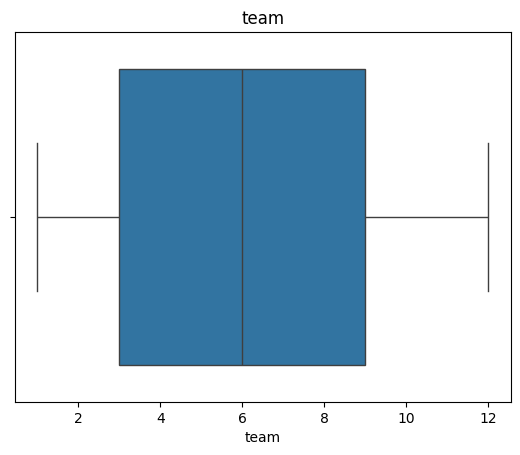

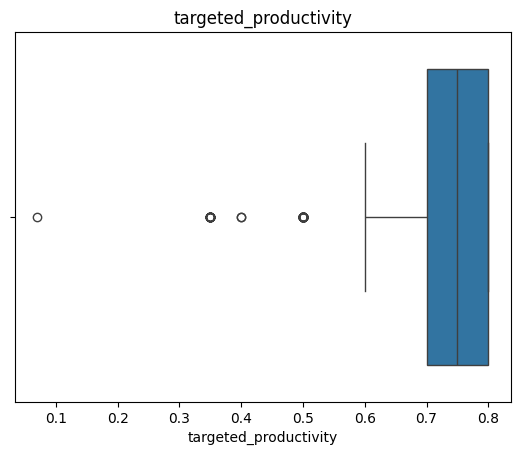

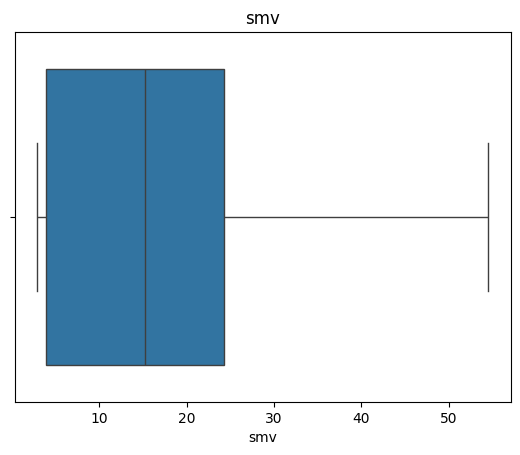

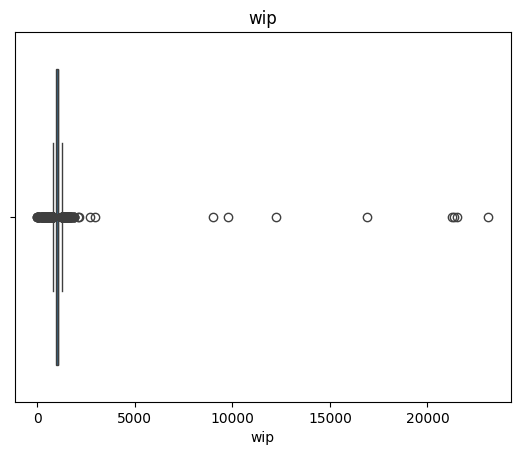

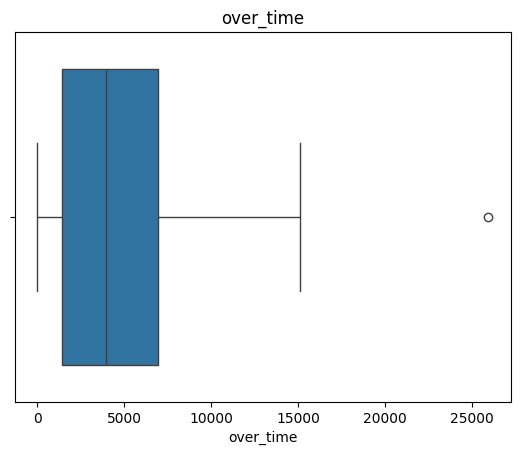

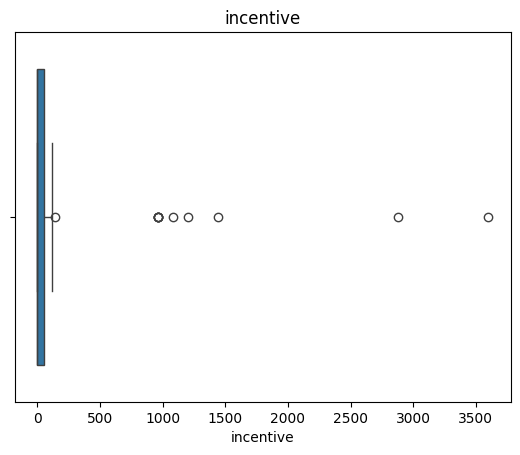

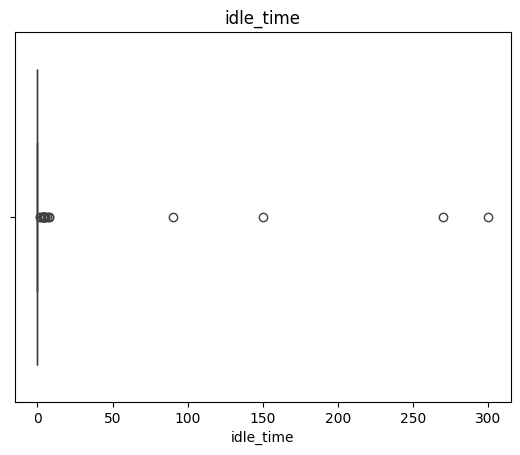

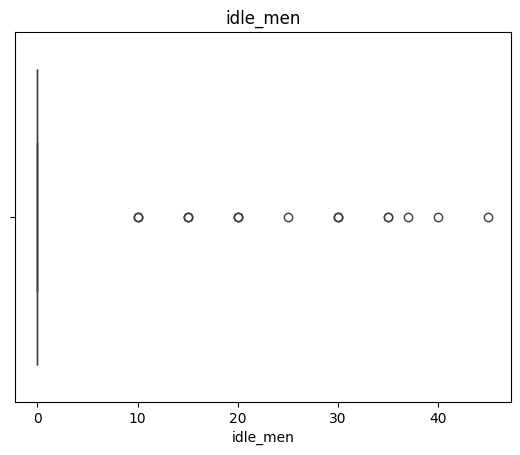

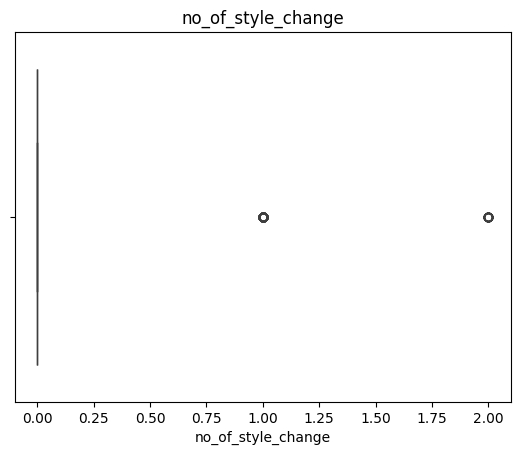

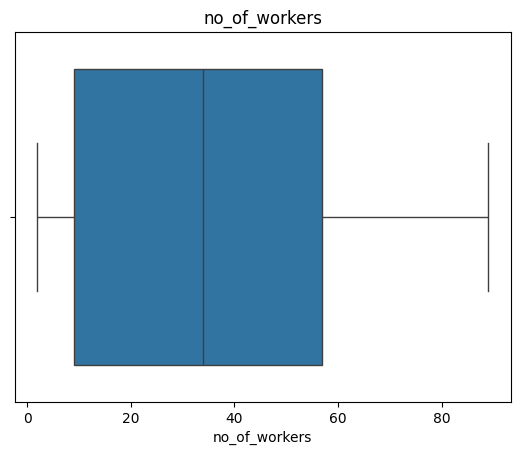

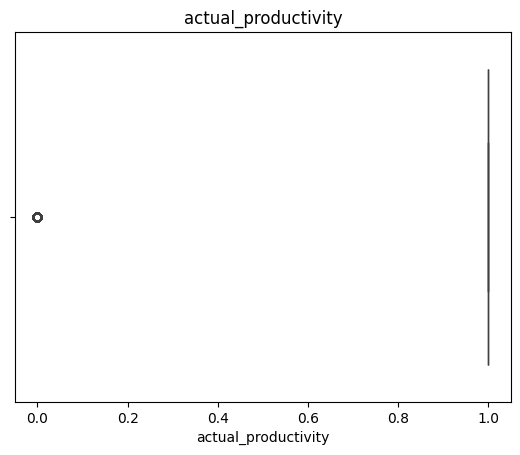

In [10]:
# Análisis univariado de outliers con boxplot
for col in df.select_dtypes(include=np.number).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [11]:
# Tratamiento de outliers (Winsorizing o IQR)
def treat_outliers_iqr(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.clip(col, lower, upper)

for col in df.select_dtypes(include=np.number).columns:
    if col != 'actual_productivity':
        df[col] = treat_outliers_iqr(df[col])

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
X = df.drop('actual_productivity', axis=1)
y = df['actual_productivity']

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## **b. Separe los datos en entrenamiento (80%) y prueba (20%) y entrene los modelos k-NN, SVM, regresión logística, árbol de clasificación, Random Forest y Naive Bayes definiendo distintos hiperparámetros para cada modelo**

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [18]:
models = {
    "Logistic Regression": LogisticRegression(),
    "k-NN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB()
}

In [20]:
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.8917
k-NN: Accuracy = 0.8708
SVM: Accuracy = 0.8875
Decision Tree: Accuracy = 0.8708
Random Forest: Accuracy = 0.8958
Naive Bayes: Accuracy = 0.8542


## **c. Utilice hiperparámetros estándar, la búsqueda en cuadrícula y búsqueda aleatoria para poder encontrar el modelo de clasificación con mejor desempeño. Luego, obtenga el mejor accuracy junto con los hiperparámetros óptimos para dicho modelo.**

In [21]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [22]:
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [23]:
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Mejor accuracy RF:", grid_rf.best_score_)
print("Mejores hiperparámetros RF:", grid_rf.best_params_)

Mejor accuracy RF: 0.8975730802792322
Mejores hiperparámetros RF: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}


In [24]:
from scipy.stats import randint

random_knn = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions={'n_neighbors': randint(3, 20)},
    n_iter=10,
    cv=5,
    random_state=42,
    scoring='accuracy'
)
random_knn.fit(X_train, y_train)

print("Mejor accuracy k-NN:", random_knn.best_score_)
print("Mejores hiperparámetros k-NN:", random_knn.best_params_)

Mejor accuracy k-NN: 0.8892397469458988
Mejores hiperparámetros k-NN: {'n_neighbors': 9}
